Tableau de contingence observé :
        Formation A  Formation B  Formation C
Réussi           45           30           25
Échoué           15           20           25

=== Résultats du test du Khi-deux ===
Statistique du Khi-deux : 7.4667
Degrés de liberté : 2
Valeur-p : 0.0239
Seuil de significativité (= 0.05) : Rejet de H0

Fréquences attendues sous l'hypothèse d'indépendance :
        Formation A  Formation B  Formation C
Réussi         37.5        31.25        31.25
Échoué         22.5        18.75        18.75

Résidus standardisés :
        Formation A  Formation B  Formation C
Réussi     1.224745    -0.223607    -1.118034
Échoué    -1.581139     0.288675     1.443376


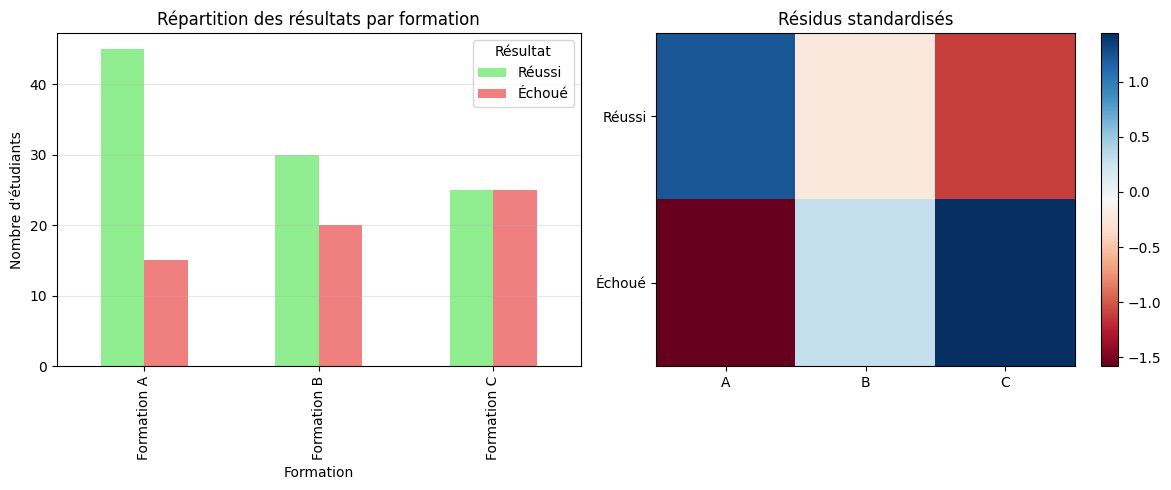


=== Mesure d'intensité de la relation ===
V de Cramér : 0.2160
Interprétation :
0.00 - 0.10 : Négligeable
0.10 - 0.20 : Faible
0.20 - 0.40 : Modérée
0.40 - 0.60 : Relativement forte
0.60 - 0.80 : Forte
0.80 - 1.00 : Très forte


In [1]:
# Test d'indépendance du Khi-deux en Python

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# 1. Création du tableau de contingence
donnees = np.array([
    [45, 30, 25],
    [15, 20, 25]
])

df = pd.DataFrame(
    donnees,
    index=['Réussi', 'Échoué'],
    columns=['Formation A', 'Formation B', 'Formation C']
)

print("Tableau de contingence observé :")
print(df)

# 2. Test du Khi-deux d'indépendance
chi2, p, dof, expected = stats.chi2_contingency(donnees)

# 3. Affichage des résultats
print("\n=== Résultats du test du Khi-deux ===")
print(f"Statistique du Khi-deux : {chi2:.4f}")
print(f"Degrés de liberté : {dof}")
print(f"Valeur-p : {p:.4f}")
print(f"Seuil de significativité (= 0.05) : {'Rejet de H0' if p < 0.05 else 'Non rejet de H0'}")

# 4. Affichage des fréquences attendues
print("\nFréquences attendues sous l'hypothèse d'indépendance :")

expected_df = pd.DataFrame(
    expected,
    index=['Réussi', 'Échoué'],
    columns=['Formation A', 'Formation B', 'Formation C']
)

print(expected_df)

# 5. Calcul des résidus standardisés
# Formule : (observé - attendu) / sqrt(attendu)
residuals = (donnees - expected) / np.sqrt(expected)

print("\nRésidus standardisés :")

residuals_df = pd.DataFrame(
    residuals,
    index=['Réussi', 'Échoué'],
    columns=['Formation A', 'Formation B', 'Formation C']
)

print(residuals_df)

# 6. Visualisation des données
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Diagramme en barres groupées
df.T.plot(kind='bar', ax=axes[0], color=['lightgreen', 'lightcoral'])
axes[0].set_title('Répartition des résultats par formation')
axes[0].set_xlabel('Formation')
axes[0].set_ylabel("Nombre d'étudiants")
axes[0].legend(title='Résultat')
axes[0].grid(axis='y', alpha=0.3)

# Heatmap des résidus
im = axes[1].imshow(residuals, cmap='RdBu', aspect='auto')
axes[1].set_title('Résidus standardisés')
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['A', 'B', 'C'])
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Réussi', 'Échoué'])

plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

# 7. Analyse complémentaire : Cramér's V
def cramers_v(chi2, n, min_dim):
    """Calcul du V de Cramér pour mesurer l'intensité de la relation"""
    return np.sqrt(chi2 / (n * (min_dim - 1)))

n = donnees.sum()          # Nombre total d'observations
min_dim = min(donnees.shape)

v_cramer = cramers_v(chi2, n, min_dim)

print("\n=== Mesure d'intensité de la relation ===")
print(f"V de Cramér : {v_cramer:.4f}")
print("Interprétation :")
print("0.00 - 0.10 : Négligeable")
print("0.10 - 0.20 : Faible")
print("0.20 - 0.40 : Modérée")
print("0.40 - 0.60 : Relativement forte")
print("0.60 - 0.80 : Forte")
print("0.80 - 1.00 : Très forte")
